# PCA part
after: https://towardsdatascience.com/pca-using-python-scikit-learn-e653f8989e60

In [30]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"# load dataset into Pandas DataFrame
df = pd.read_csv(url, names=['sepal length','sepal width','petal length','petal width','target'])

In [85]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.072108,0.036431,0.025042,0.021196,0.020549,0.021635,0.023759,0.026354,0.028735,0.030104,...,0.023975,0.025887,0.027067,0.027456,0.027124,0.026254,0.025094,0.023901,0.022903,0.022296
1,0.061064,0.044621,0.035331,0.030409,0.028131,0.027507,0.027915,0.028878,0.029944,0.030661,...,0.020333,0.023359,0.025686,0.027170,0.027853,0.027949,0.027771,0.027641,0.027814,0.028435
2,0.057668,0.041482,0.032828,0.028454,0.026595,0.026303,0.026998,0.028229,0.029557,0.030519,...,0.021239,0.023913,0.025789,0.026798,0.027070,0.026901,0.026661,0.026712,0.027359,0.028828
3,0.063552,0.044364,0.034170,0.029013,0.026746,0.026248,0.026868,0.028126,0.029562,0.030691,...,0.020326,0.023123,0.025268,0.026765,0.027803,0.028697,0.029807,0.031452,0.033814,0.036801
4,0.046140,0.033944,0.028222,0.025823,0.025330,0.026018,0.027406,0.029065,0.030534,0.031348,...,0.022375,0.024990,0.026723,0.027397,0.027048,0.025916,0.024359,0.022743,0.021374,0.020484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77016,0.035065,0.050531,0.069587,0.088635,0.101113,0.101554,0.090438,0.073213,0.055367,0.039815,...,0.034867,0.033052,0.030971,0.028753,0.026508,0.024326,0.022270,0.020380,0.018678,0.017173
77017,-0.017273,-0.015311,-0.013510,-0.011863,-0.010361,-0.008994,-0.007751,-0.006623,-0.005601,-0.004674,...,0.041625,0.044396,0.046695,0.048343,0.049186,0.049118,0.048107,0.046206,0.043546,0.040311
77018,0.014778,0.029299,0.053896,0.082532,0.092869,0.074511,0.045728,0.021849,0.005404,-0.005529,...,-0.000744,-0.001206,-0.001742,-0.002360,-0.003071,-0.003887,-0.004822,-0.005893,-0.007117,-0.008512
77019,0.013719,0.027766,0.053409,0.087524,0.105136,0.087391,0.054742,0.027674,0.009490,-0.002385,...,-0.000817,-0.001339,-0.001946,-0.002650,-0.003464,-0.004403,-0.005486,-0.006735,-0.008172,-0.009820


In [7]:
features = ['sepal length', 'sepal width', 'petal length', 'petal width']

In [8]:
# Separating out the features
x = df.loc[:, features].values# Separating out the target
y = df.loc[:,['target']].values# Standardizing the features
x = StandardScaler().fit_transform(x)

In [9]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])

In [10]:
principalDf

,principal component 1,principal component 2
0,-2.264542,0.505704
1,-2.086426,-0.655405
2,-2.367950,-0.318477
3,-2.304197,-0.575368
4,-2.388777,0.674767
...,...,...
145,1.870522,0.382822
146,1.558492,-0.905314
147,1.520845,0.266795
148,1.376391,1.016362


In [11]:
finalDf = pd.concat([principalDf, df[['target']]], axis = 1)
finalDf

,principal component 1,principal component 2,target
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa
...,...,...,...
145,1.870522,0.382822,Iris-virginica
146,1.558492,-0.905314,Iris-virginica
147,1.520845,0.266795,Iris-virginica
148,1.376391,1.016362,Iris-virginica


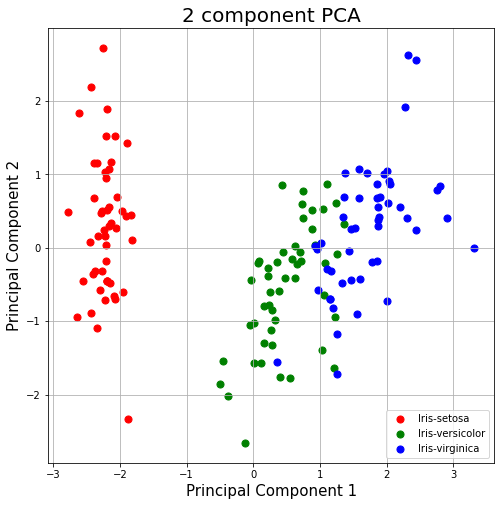

In [12]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)
targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['target'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

In [13]:
#Variation explained
print(pca.explained_variance_ratio_)
np.sum(pca.explained_variance_ratio_)

[0.72770452 0.23030523]


0.9580097536148199

## On the Centerline Dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [32]:
# path='/groups/zimmer/Ulises/code/skeleton_OLD/'
# df=pd.read_csv(path+'second_der_np_new.csv', header=None)
# df.shape

In [197]:
#path='/groups/zimmer/Ulises/code/skeleton_OLD/spline/second_der_np_new.csv'
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-10-48_control_worm1_spline_K.csv'
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-06-30_18-17-47_chemotaxis_worm5_spline_K.csv'
df=pd.read_csv(path, header=None)

df.shape
df.dropna(inplace=True)
features = np.arange(0,99)# Separating out the features
x = df.loc[:, features].values
print(x.shape)

(7361, 99)


In [199]:
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(x)
principalComponents.shape
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2','PC3','PC4','PC5'])

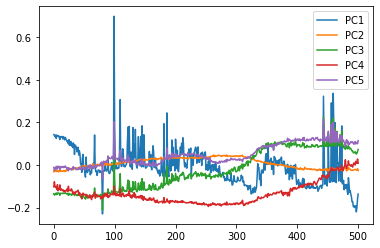

In [187]:
for pc in principalDf:
    principalDf.loc[0:500,pc].plot(legend=True)

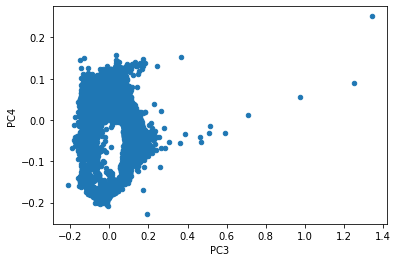

In [190]:
x_pc='PC3'
y_pc='PC4'
principalDf.plot.scatter(x=x_pc, y=y_pc)

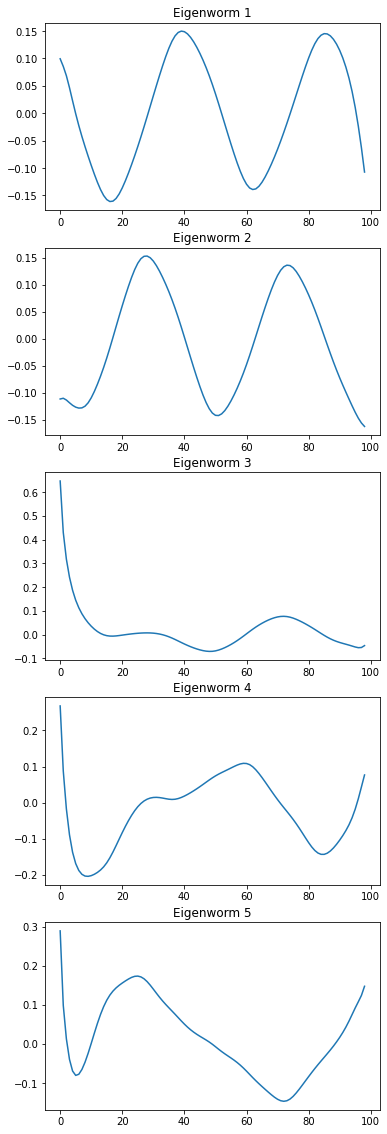

In [200]:
fig1, f1_axs = plt.subplots(ncols=1, nrows=5, constrained_layout=False, figsize=(6,20))
for i, eigenworm in enumerate(pca.components_):
    f1_axs[i].plot(eigenworm)
    f1_axs[i].set_title('Eigenworm ' +str(i+1))
#     f1_axs[0,i].set_xlabel('Time (frames)')
#     f1_axs[0,i].set_ylabel('Signal Amplitude (a.u)')
#         fig.plot(eigenworm)
#     .title('Eingenworm ' +str(i))
#     plt.show()
# i=i+1
# f1_axs[i].plot(pca.explained_variance_ratio_.cumsum())
# f1_axs[i].plot(pca.explained_variance_ratio_.cumsum(), 'bo')
# f1_axs[i].ylim([0,1])
# f1_axs[i].ylabel('Variance Explained')
# f1_axs[i].xlabel('PC')
# f1_axs[i].xticks(np.arange(5), principalDf.columns)

[0.34425021 0.30288543 0.14344507 0.06781153 0.05123098]


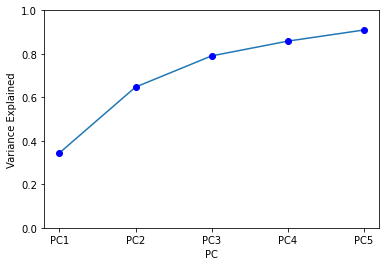

In [201]:
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.plot(pca.explained_variance_ratio_.cumsum(), 'bo')
plt.ylim([0,1])
plt.ylabel('Variance Explained')
plt.xlabel('PC')
plt.xticks(np.arange(5), principalDf.columns)
print(pca.explained_variance_ratio_)

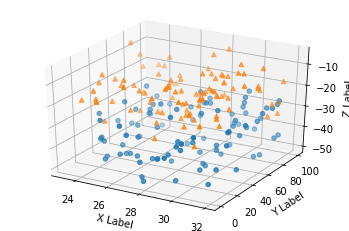

In [17]:
#3D plotting
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)


def randrange(n, vmin, vmax):
    '''
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    '''
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

n = 100

# For each set of style and range settings, plot n random points in the box
# defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = randrange(n, 23, 32)
    ys = randrange(n, 0, 100)
    zs = randrange(n, zlow, zhigh)
    ax.scatter(xs, ys, zs, marker=m)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [ ]:

# Import pandas as pd
import pandas as pd

# Read in the CSV file: df
df=principalDf

# Import figure from bokeh.plotting
from bokeh.plotting import figure
from bokeh.io import push_notebook, show, output_notebook 

# Create the figure: p
p = figure(x_axis_label='PC2', y_axis_label='PC3')

# Plot mpg vs hp by color
p.circle(df['PC2'], df['PC3'], size=10)

# Specify the name of the output file and show the result
output_notebook()
show(p)

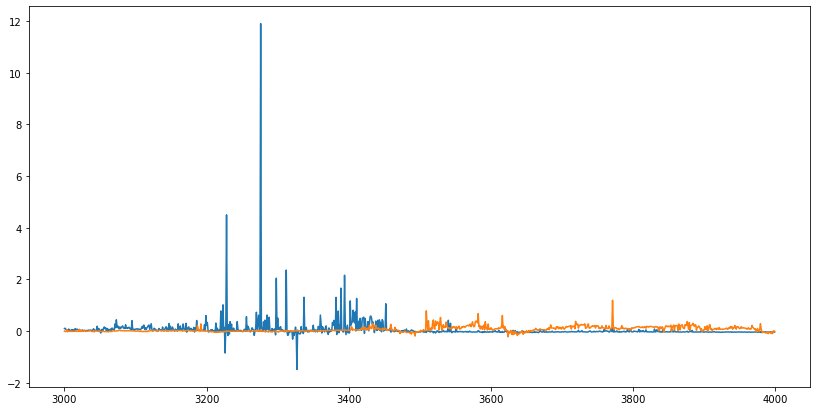

In [12]:
plt.figure(figsize=(14,7))
plt.plot(principalDf['PC1'][3000:4000])
plt.plot(principalDf['PC2'][3000:4000])

In [20]:
pca.explained_variance_ratio_

array([0.36016637, 0.16643133, 0.13146125, 0.10535605, 0.07447364])

(-1.0, 1.0)

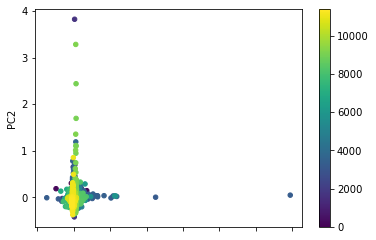

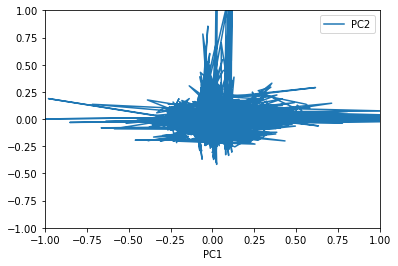

In [13]:
fig = principalDf.plot.scatter(x='PC1', y='PC2',c=principalDf.index, colormap='viridis')
fig= principalDf.plot(x='PC1', y='PC2')
fig.set_xlim([-1,1])
fig.set_ylim([-1,1])

In [14]:
plt.figure(figsize=(7,7))
for k,d in principalDf:
    plt.scatter(k,d)
#plt.scatter(principalDf['PC1'][0:10],principalDf['PC2'][0:10])
#plt.plot(principalDf['PC2'][3000:4000])

ValueError: too many values to unpack (expected 2)

<Figure size 504x504 with 0 Axes>

In [ ]:
k,d=principalDf

In [ ]:
d

In [1]:
plt.scatter(principalDf['PC1'][0:4000],principalDf['PC2'][0:4000],c=np.arange(0,4000), vmin=0, vmax=4000)
plt.colorbar()
# ax_lim=0.2
# plt.xlim(-ax_lim,ax_lim)
# plt.ylim(-ax_lim,ax_lim)

NameError: name 'plt' is not defined

(-0.2, 0.2)

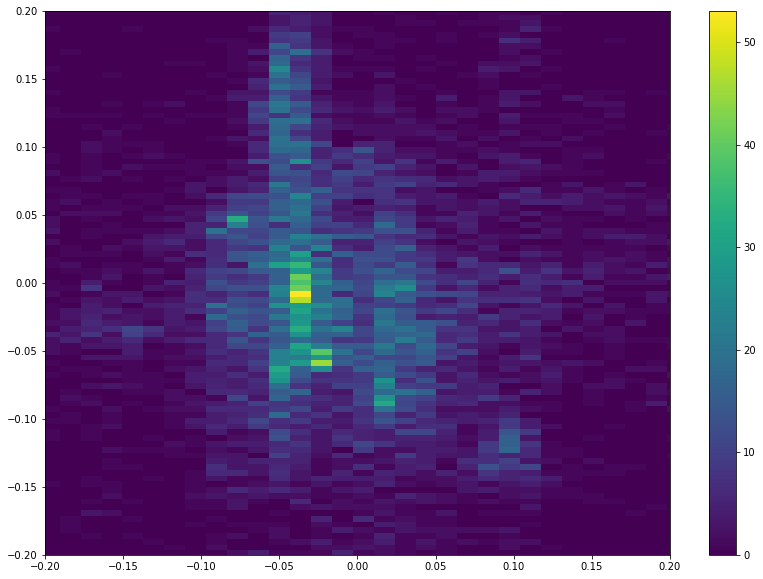

In [16]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

(-0.5, 0.5)

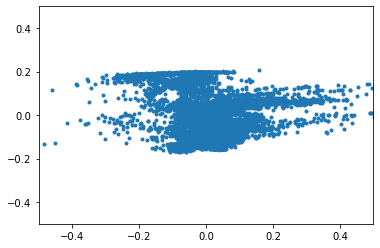

In [17]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

(-0.5, 0.5)

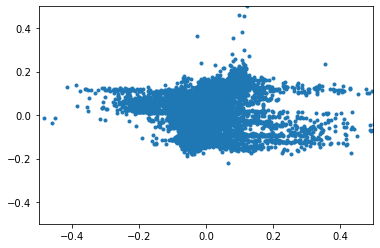

In [18]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [99]:
import re
dir=re.split('-channel',re.split('/',input_filename)[-1])[0]

In [102]:
dir+'_skeleton_X_coords.csv'

'2020-06-05_16-46-41_worm1_skeleton_X_coords.csv'

In [ ]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)